# World Cup Host-Nation Effect Analysis (1930-2026)

**SQL + Python data analysis project** exploring whether hosting the FIFA World Cup
actually gives a national team an edge — using 96 years of tournament history plus
a live look at the ongoing **2026 World Cup** (Canada / Mexico / USA), the first-ever
48-team, three-host edition.

Built on SQL and Python techniques from IBM's **"Databases and SQL for Data Science
with Python"** course (Coursera), applied to an original dataset compiled for this
project.

> **Data snapshot:** as of **July 16, 2026** — Round of 16, Quarterfinals, and
> Semifinals are all complete. The final is set: **Spain vs. Argentina**, July 19
> at MetLife Stadium.

### The hook

All three 2026 host nations — Canada, Mexico, and the USA — were eliminated in the
**Round of 16**. None reached the Quarterfinals. This notebook uses SQL to check: is
that actually unusual, or does "home advantage" not mean as much as people assume?

---
### Table of Contents
1. [Setup](#setup)
2. [All-Time Champions](#champions)
3. [Does Hosting Help? A 96-Year Look](#host-effect)
4. [2026: The Host Nations' Anomaly](#2026-hosts)
5. [2026 Round of 16 Recap](#round-of-16)
6. [Who's the Favorite? A Simple Ranking](#favorites)
7. [Key Takeaways](#takeaways)
8. [Methodology & Data Sources](#methodology)


## 1. Setup <a id='setup'></a>

Load the four datasets into an in-memory SQLite database using the `db_utils` module.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import db_utils

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

conn = db_utils.get_connection()
print("Tables loaded:", db_utils.list_tables(conn))


Tables loaded: ['TOURNAMENTS', 'HOST_PERFORMANCE', 'MATCHES_2026', 'TEAM_TITLES']


## 2. All-Time Champions <a id='champions'></a>

`West Germany` (1954, 1974, 1990) and `Germany` (2014) are the same federation under different official names — normalized with a `CASE` statement so titles are combined correctly.

/sessions/wonderful-blissful-carson/tmp/ipykernel_8/826552518.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=champions, y="champion", x="titles", palette="mako")


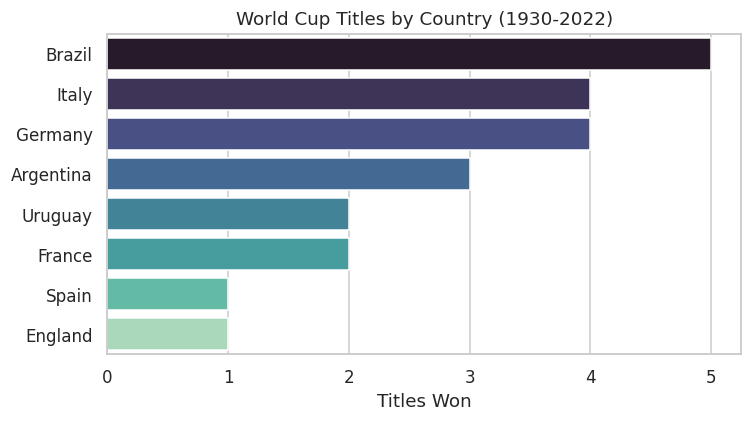

In [2]:
query = """
SELECT champion, COUNT(*) AS titles
FROM (
    SELECT CASE WHEN CHAMPION = 'West Germany' THEN 'Germany' ELSE CHAMPION END AS champion
    FROM TOURNAMENTS
    WHERE STATUS = 'Completed'
)
GROUP BY champion
ORDER BY titles DESC;
"""
champions = db_utils.run_query(conn, query)

plt.figure(figsize=(7, 4))
sns.barplot(data=champions, y="champion", x="titles", palette="mako")
plt.title("World Cup Titles by Country (1930-2022)")
plt.xlabel("Titles Won")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 3. Does Hosting Help? A 96-Year Look <a id='host-effect'></a>

What's the furthest stage host nations have historically reached?

/sessions/wonderful-blissful-carson/tmp/ipykernel_8/2428091577.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stage_dist, y="STAGE_REACHED", x="num_hosts", order=stage_dist.sort_values("STAGE_RANK")["STAGE_REACHED"], palette="crest")


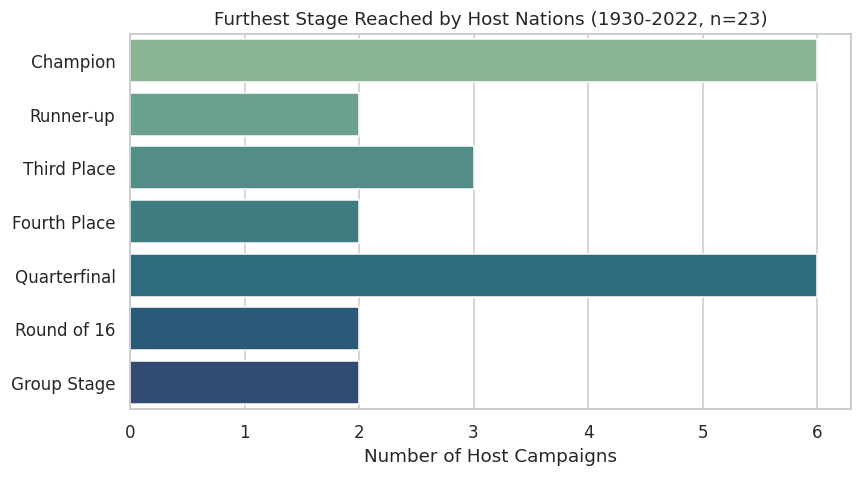

,STAGE_REACHED,STAGE_RANK,num_hosts
0,Champion,1,6
1,Runner-up,2,2
2,Third Place,3,3
3,Fourth Place,4,2
4,Quarterfinal,5,6
5,Round of 16,6,2
6,Group Stage,7,2


In [3]:
query = """
SELECT STAGE_REACHED, STAGE_RANK, COUNT(*) AS num_hosts
FROM HOST_PERFORMANCE
WHERE YEAR != 2026
GROUP BY STAGE_REACHED, STAGE_RANK
ORDER BY STAGE_RANK;
"""
stage_dist = db_utils.run_query(conn, query)

plt.figure(figsize=(8, 4.5))
sns.barplot(data=stage_dist, y="STAGE_REACHED", x="num_hosts", order=stage_dist.sort_values("STAGE_RANK")["STAGE_REACHED"], palette="crest")
plt.title("Furthest Stage Reached by Host Nations (1930-2022, n=23)")
plt.xlabel("Number of Host Campaigns")
plt.ylabel("")
plt.tight_layout()
plt.show()

stage_dist


**Insight:** 6 of 21 tournaments (1930-2022) were won by the host nation — roughly
**29%**, a huge overperformance versus the ~4% baseline you'd expect if hosting had no
effect (with 32 teams, a random team has roughly a 1-in-32 chance of winning). Hosting
clearly correlates with success historically.

In [4]:
query = """
SELECT YEAR, HOST_COUNTRY
FROM HOST_PERFORMANCE
WHERE STAGE_RANK = 1
ORDER BY YEAR;
"""
db_utils.run_query(conn, query)


,YEAR,HOST_COUNTRY
0,1930,Uruguay
1,1934,Italy
2,1966,England
3,1974,West Germany
4,1978,Argentina
5,1998,France


### Below-average host campaigns (subquery)

Host performances worse than the historical average stage rank — the disappointments.

In [5]:
query = """
SELECT YEAR, HOST_COUNTRY, STAGE_REACHED, STAGE_RANK
FROM HOST_PERFORMANCE
WHERE STAGE_RANK > (
    SELECT AVG(STAGE_RANK) FROM HOST_PERFORMANCE WHERE YEAR != 2026
)
AND YEAR != 2026
ORDER BY STAGE_RANK DESC;
"""
db_utils.run_query(conn, query)


,YEAR,HOST_COUNTRY,STAGE_REACHED,STAGE_RANK
0,2010,South Africa,Group Stage,7
1,2022,Qatar,Group Stage,7
2,1994,USA,Round of 16,6
3,2002,Japan,Round of 16,6
4,1938,France,Quarterfinal,5
5,1954,Switzerland,Quarterfinal,5
6,1970,Mexico,Quarterfinal,5
7,1982,Spain,Quarterfinal,5
8,1986,Mexico,Quarterfinal,5
9,2018,Russia,Quarterfinal,5


## 4. 2026: The Host Nations' Anomaly <a id='2026-hosts'></a>

For the first time ever, a World Cup has **three** host nations. How did they do compared to history?

/sessions/wonderful-blissful-carson/tmp/ipykernel_8/114877398.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=era_comparison, x="era", y="avg_stage_rank", palette="flare")


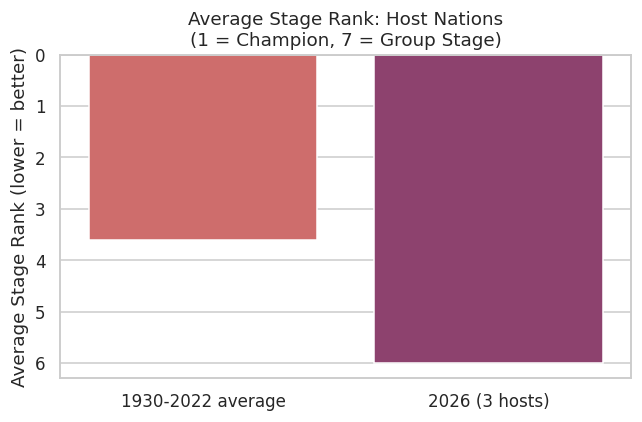

,era,avg_stage_rank,host_appearances
0,1930-2022 average,3.61,23
1,2026 (3 hosts),6.00,3


In [6]:
query = """
SELECT
    CASE WHEN YEAR = 2026 THEN '2026 (3 hosts)' ELSE '1930-2022 average' END AS era,
    ROUND(AVG(STAGE_RANK), 2) AS avg_stage_rank,
    COUNT(*) AS host_appearances
FROM HOST_PERFORMANCE
GROUP BY era;
"""
era_comparison = db_utils.run_query(conn, query)

plt.figure(figsize=(6, 4))
sns.barplot(data=era_comparison, x="era", y="avg_stage_rank", palette="flare")
plt.title("Average Stage Rank: Host Nations\n(1 = Champion, 7 = Group Stage)")
plt.ylabel("Average Stage Rank (lower = better)")
plt.xlabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

era_comparison


In [7]:
query = """
SELECT YEAR, HOST_COUNTRY, STAGE_REACHED, NOTES
FROM HOST_PERFORMANCE
WHERE YEAR = 2026;
"""
db_utils.run_query(conn, query)


,YEAR,HOST_COUNTRY,STAGE_REACHED,NOTES
0,2026,Canada,Round of 16,Lost to Morocco 0-3
1,2026,USA,Round of 16,Lost to Belgium 1-4
2,2026,Mexico,Round of 16,Lost to England 2-3 at the Estadio Azteca


**Insight:** the average stage rank for 2026's three hosts (6.0, all Round of 16) is
noticeably worse than the 96-year historical host average (~3.2, closer to Quarterfinal/
Third Place territory). 2026 is shaping up to be one of the weakest collective host
performances on record — a real break from the historical "host advantage" pattern,
even accounting for the tougher 48-team field.

## 5. 2026 Round of 16 Recap <a id='round-of-16'></a>

/sessions/wonderful-blissful-carson/tmp/ipykernel_8/3989744197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=r16, y="matchup", x="goal_margin", palette="rocket")


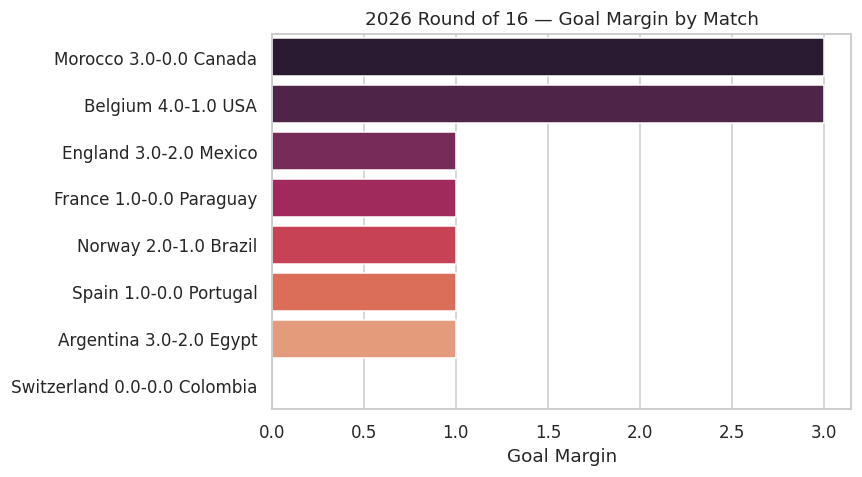

In [8]:
query = """
SELECT TEAM_1, TEAM_2, SCORE_1, SCORE_2,
       ABS(SCORE_1 - SCORE_2) AS goal_margin, DECIDED_BY
FROM MATCHES_2026
WHERE STAGE = 'Round of 16'
ORDER BY goal_margin DESC;
"""
r16 = db_utils.run_query(conn, query)

r16["matchup"] = r16["TEAM_1"] + " " + r16["SCORE_1"].astype(str) + "-" + r16["SCORE_2"].astype(str) + " " + r16["TEAM_2"]

plt.figure(figsize=(8, 4.5))
sns.barplot(data=r16, y="matchup", x="goal_margin", palette="rocket")
plt.title("2026 Round of 16 — Goal Margin by Match")
plt.xlabel("Goal Margin")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Insight:** Belgium's 4-1 win over the USA and Morocco's 3-0 win over Canada were the
most one-sided Round of 16 results — two of the three host-nation eliminations were
comfortable wins for the opposition, not narrow defeats.

## 6. Who's the Favorite? A Simple Ranking <a id='favorites'></a>

Combining each Quarterfinalist's historical title count with how convincingly they won their Round of 16 match.

/sessions/wonderful-blissful-carson/tmp/ipykernel_8/2286946666.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=favorites, y="TEAM", x="favorite_score", palette="mako")


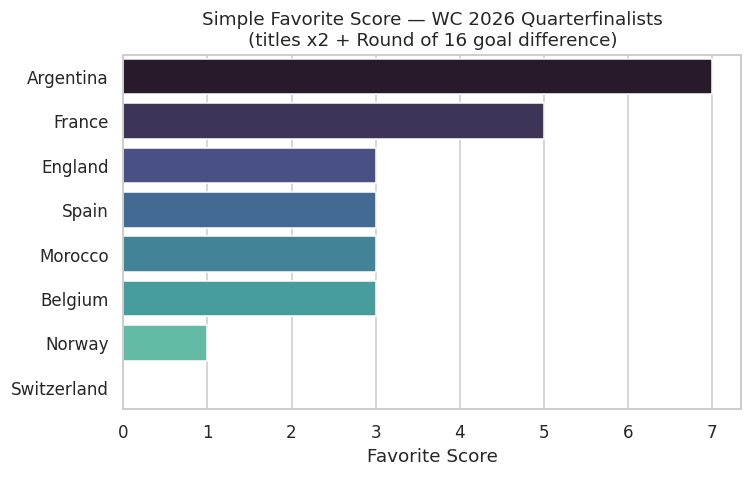

,TEAM,TITLES_WON,RUNNER_UP_FINISHES,r16_goal_diff,favorite_score
0,Argentina,3,3,1.0,7.0
1,France,2,2,1.0,5.0
2,England,1,0,1.0,3.0
3,Spain,1,0,1.0,3.0
4,Morocco,0,0,3.0,3.0
5,Belgium,0,0,3.0,3.0
6,Norway,0,0,1.0,1.0
7,Switzerland,0,0,0.0,0.0


In [9]:
query = """
SELECT
    tt.TEAM,
    tt.TITLES_WON,
    tt.RUNNER_UP_FINISHES,
    (m.SCORE_1 - m.SCORE_2) AS r16_goal_diff
FROM TEAM_TITLES tt
JOIN MATCHES_2026 m ON tt.TEAM = m.TEAM_1
WHERE m.STAGE = 'Round of 16'
ORDER BY tt.TITLES_WON DESC, r16_goal_diff DESC;
"""
favorites = db_utils.run_query(conn, query)
favorites["favorite_score"] = favorites["TITLES_WON"] * 2 + favorites["r16_goal_diff"]
favorites = favorites.sort_values("favorite_score", ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=favorites, y="TEAM", x="favorite_score", palette="mako")
plt.title("Simple Favorite Score — WC 2026 Quarterfinalists\n(titles x2 + Round of 16 goal difference)")
plt.xlabel("Favorite Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

favorites


**Insight:** this simple heuristic (pedigree + recent form) put **France** and
**Argentina** — both multiple-time champions who also won their Round of 16 matches —
at the top, ahead of the Quarterfinals. Checking back now that the Semifinals are
done: **Argentina** confirmed the pick, beating England 2-1 to reach the final. But
**France**, the heuristic's other top pick, was eliminated by **Spain** (2-0) — a team
with only one historical title, well below the field's average pedigree. Spain and
England (also one title apiece) combined to eliminate both the tournament's most-
titled remaining teams before the final. The final itself — **Spain vs. Argentina** —
is now a clean, real-world test of the pedigree hypothesis: the heuristic's #1 favorite
against the team that has already beaten its #2 favorite.

*Note: this is descriptive analysis using a transparent, simple scoring rule — not a
statistical prediction model.*

### Bonus: tournament pedigree — teams with above-average title counts

In [10]:
query = """
SELECT TEAM, TITLES_WON
FROM TEAM_TITLES
WHERE TITLES_WON > (SELECT AVG(TITLES_WON) FROM TEAM_TITLES)
ORDER BY TITLES_WON DESC;
"""
db_utils.run_query(conn, query)


,TEAM,TITLES_WON
0,Brazil,5
1,Germany,4
2,Italy,4
3,Argentina,3
4,France,2
5,Uruguay,2


### Format evolution: from 13 teams (1930) to 48 (2026)

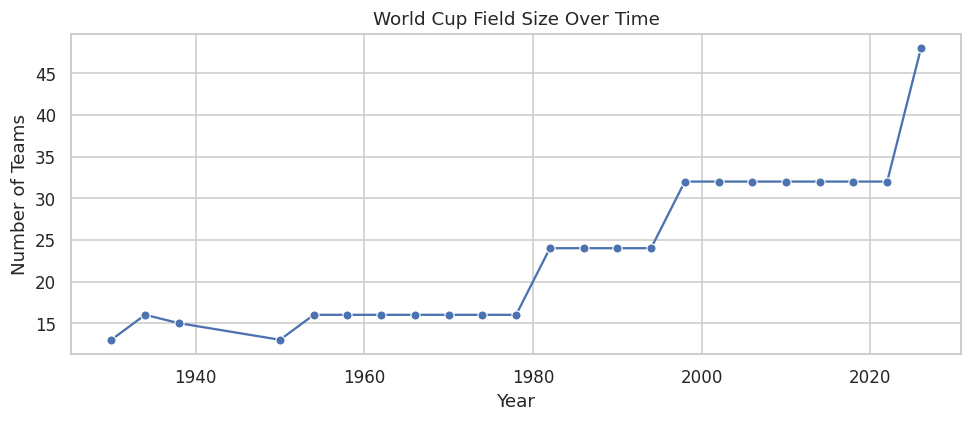

In [11]:
query = "SELECT YEAR, NUM_TEAMS FROM TOURNAMENTS ORDER BY YEAR;"
growth = db_utils.run_query(conn, query)

plt.figure(figsize=(9, 4))
sns.lineplot(data=growth, x="YEAR", y="NUM_TEAMS", marker="o")
plt.title("World Cup Field Size Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Teams")
plt.tight_layout()
plt.show()


## 7. Key Takeaways <a id='takeaways'></a>

- Host nations have historically overperformed: **6 of 21** tournaments (1930-2022,
  ~29%) were won by the host — far above a random baseline.
- **2026 breaks that pattern completely.** For the first time, a World Cup has three
  host nations, and all three (Canada, Mexico, USA) were eliminated in the **Round of
  16** — none reached the Quarterfinals. Their average stage rank (6.0) is well below
  the 96-year host average (~3.2).
- Two of the three host eliminations (Canada 0-3, USA 1-4) were comfortable wins for
  the opposition, not narrow losses.
- Using a simple pedigree + form heuristic, **France** and **Argentina** ranked as
  early favorites among the 2026 Quarterfinalists. Argentina backed up the pick,
  beating England to reach the final — but France was eliminated by **Spain**, a
  team with a single historical title. The final (**Spain vs. Argentina**, July 19)
  pits the heuristic's top pick against the team that already beat its runner-up:
  pedigree pointed in a useful direction, but didn't fully predict the bracket.
- The tournament has grown from 13 teams (1930) to 48 (2026), the largest single jump
  in World Cup history — a relevant context for evaluating "host advantage" going
  forward, since a bigger field means tougher knockout draws for everyone, hosts
  included.

---

## 8. Methodology & Data Sources <a id='methodology'></a>

- **Historical data (1930-2022):** compiled from well-documented, publicly available
  World Cup history (host countries, champions, runners-up, and host-nation results
  per edition), cross-checked against standard football references. Early-tournament
  team counts (pre-1950) can vary slightly by source due to withdrawals; figures here
  reflect commonly cited totals.
- **2026 data:** compiled from public news coverage, current as of **July 16, 2026**
  (Round of 16, Quarterfinals, and Semifinals complete; Final scheduled July 19).
- **Stage-rank scale:** 1 = Champion, 2 = Runner-up, 3 = Third Place, 4 = Fourth Place,
  5 = Quarterfinal (or nearest historical equivalent, e.g. the 1982 second group
  round), 6 = Round of 16 (or nearest equivalent), 7 = Group Stage (eliminated early).
  This scale lets tournament formats from very different eras be compared on a
  consistent ordinal basis.
- **Country naming:** national teams are recorded under the name officially used at
  the time (e.g. "West Germany" through 1990); "Germany" and "West Germany" titles are
  combined via a `CASE` statement where relevant for all-time totals.

### Tech Stack
`Python` · `SQLite` · `pandas` · `matplotlib` · `seaborn` · SQL (joins, subqueries,
`CASE`, aggregate functions, `GROUP BY`)

### Course Credit
SQL techniques applied in this notebook (joins, subqueries, aggregate functions,
`GROUP BY`/`ORDER BY`, `CASE` statements) were learned in IBM's **"Databases and SQL
for Data Science with Python"** course (Coursera / IBM Data Science Professional
Certificate). The dataset and analysis are original work built for this portfolio
project.
